# Import Libraries and implement logger

In [247]:
## IMPORT LIBRARIES
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from datetime import datetime
from dataclasses import dataclass
from sklearn. model_selection import train_test_split
from sklearn. preprocessing import MinMaxScaler

In [248]:
# CREATE LOGGER FOR JUPYTER NOTEBOOKS
def setup_logger():
    # Create logger instance
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    # Clear existing, avoid duplicate logs
    if logger.hasHandlers():
        logger.handlers.clear()
    
    # Create FileHandler in overrite mode
    file_handler = logging.FileHandler('../../logvisualizer.log', mode ='w')

    # Set format
    formatter = logging.Formatter('%(asctime)s - %(levelno)s - %(lineno)d - %(module)s - %(message)s')
    file_handler.setFormatter(formatter)

    # Add FileHandler to logger
    logger.addHandler(file_handler)

    return logger

logger = setup_logger()

# Inspcet the data read in after the data preperation

In [249]:
## Define function for inspection
def inspect_raw_data(df, output_path=None):
    '''
    Inspect a DataFrame and save info to a text file.
    Parameters:
    df : pandas DataFrame
    output_path : Path or str, optional
        Where to save the output file. If None and save_to_file is True,
        will use current directory
    '''

    # Set display options
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    # Prepare the information
    info_text = []
    info_text.append(f"Generated on: {datetime.now()}")
    info_text.append(f"Shape: {df.shape}")
    
    # Get info in string format
    buffer = StringIO()
    df.info(buf=buffer)
    info_text.append(f"\nDataFrame Info:")
    info_text.append(buffer.getvalue())

    # Add first 5 rows
    buffer_head = StringIO()
    df.head().to_string(buf=buffer_head)
    info_text.append(f"\nFirst 5 rows:")
    info_text.append(buffer_head.getvalue())

    # Add last 5 rows
    buffer_tail = StringIO()
    df.tail().to_string(buf=buffer_tail)
    info_text.append(f"\nLast 5 rows:")
    info_text.append(buffer_tail.getvalue())
    
    # Join all information
    full_report = '\n'.join(info_text)
    output_path = Path(output_path)
    output_path.write_text(full_report)
    logger.info(f"Report saved to: {output_path}")
    
    return full_report

In [250]:
# READ IN
data_path = Path('..') / '..' / 'data' / 'processed' / 'DataPrep' 
for file in data_path.glob('*.csv'):
    logger.info(f'Available csv file: {file.name}')

# Read in data
df_eso = pd.read_csv(data_path / 'df_eso.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']
df_ger = pd.read_csv(data_path / 'df_ger.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']

# CALL FUNCTION FOR INSPECTION 
_ = inspect_raw_data(df_eso, output_path=Path(f'{data_path}/../Visualizer/eso/df_eso.txt'))
_ = inspect_raw_data(df_ger, output_path=Path(f'{data_path}/../Visualizer/ger/df_ger.txt'))

# Compare features of the whole dataset
Check eso_inspection.txt and smard_inspection.txt in the 'processed' directory.

The table shows the features that are manually assignable at the first check.

                                               
| UK (eso)      | German (ger)                                                      |
|------------|------------------------------------------------------------------|
| Power Generation by Source:                                                   |
| GAS        | Erzeugung_Erdgas [MWh]                                           |
| COAL       | Erzeugung_Steinkohle [MWh] + Erzeugung_Braunkohle [MWh]          |
| NUCLEAR    | Erzeugung_Kernenergie [MWh]                                      |
| WIND       | Erzeugung_Wind Offshore [MWh] + Erzeugung_Wind Onshore [MWh]     |
| HYDRO      | Erzeugung_Wasserkraft [MWh]                                      |
| BIOMASS    | Erzeugung_Biomasse [MWh]                                         |
| SOLAR      | Erzeugung_Photovoltaik [MWh]                                     |
| STORAGE    | Erzeugung_Pumpspeicher [MWh]                                     |
| Demand/Load:                                                                  |
| ENGLAND_WALES_DEMAND  | Stromverbrauch_Gesamt (Netzlast) [MWh]                |
| PUMP_STORAGE_PUMPING  | Stromverbrauch_Pumpspeicher [MWh]                     |
| Cross-border flows (various interconnector flows):                            |          
| IFA_FLOW              | Stromfluss_Niederlande (Export/Import)                |
| BRITNED_FLOW          | Stromfluss_Frankreich (Export/Import)                 |
| MOYLE_FLOW            | Stromfluss_Polen (Export/Import)                      |
| etc.                  | etc.                                                  |
| System Balancing:                                                             |
| Energy Imbalance          |  Ausgleichsenergie_Volumen (+/-) [MWh]            |
| Frequency Control         |  Sekund_Abgerufene Menge (+/-) [MWh]              |
| Positive/Negative Reserve |   Minutenreserve_Abgerufene Menge (+/-) [MWh]     |


# Visualize comparable feature of the whole dataset

In [251]:
# DEFINE VISUALIZER CLASS
@dataclass
class Visualizer:
    df_eso: pd.DataFrame
    df_ger: pd.DataFrame

    def __post_init__(self):
        self.eso_power_gen = {
            'FOSSIL': self.df_eso['GAS'] + self.df_eso['COAL'],
            'NUCLEAR': self.df_eso['NUCLEAR'],
            'RENEW': self.df_eso['WIND'] + self.df_eso['HYDRO'] + self.df_eso['BIOMASS'] + self.df_eso['SOLAR'],
            'PUMP_STORAGE': self.df_eso['STORAGE']
        }

        self.eso_demand = {
            'OVERALL': self.df_eso['ENGLAND_WALES_DEMAND'],
            'PUMP_STORAGE': self.df_eso['PUMP_STORAGE_PUMPING']
        }

        self.eso_balancing = {
            'Energy Imbalance': self.df_eso['Energy Imbalance (MWh)'],
            'Frequency Control': self.df_eso['Frequency Control Offers (MWh)'] - self.df_eso['Frequency Control Bids (MWh)'],
            'Positive Reserve': self.df_eso['Positive Reserve (MWh)'],
            'Negative Reserve': self.df_eso['Negative Reserve (MWh)']
        }

        self.ger_power_gen = {
            'FOSSIL': self.df_ger['Erzeugung_Erdgas [MWh]'] + self.df_ger['Erzeugung_Steinkohle [MWh]'] + self.df_ger['Erzeugung_Braunkohle [MWh]'],
            'NUCLEAR': self.df_ger['Erzeugung_Kernenergie [MWh]'],
            'RENEW': self.df_ger['Erzeugung_Wind Offshore [MWh]'] + self.df_ger['Erzeugung_Wind Onshore [MWh]'] +
                     self.df_ger['Erzeugung_Wasserkraft [MWh]'] + self.df_ger['Erzeugung_Biomasse [MWh]'] +
                     self.df_ger['Erzeugung_Photovoltaik [MWh]'],
            'PUMP_STORAGE': self.df_ger['Erzeugung_Pumpspeicher [MWh]']
        }

        self.ger_demand = {
            'OVERALL': self.df_ger['Stromverbrauch_Gesamt (Netzlast) [MWh]'],
            'PUMP_STORAGE': self.df_ger['Stromverbrauch_Pumpspeicher [MWh]']
        }

        self.ger_balancing = {
            'Energy Imbalance': self.df_ger['Ausgleichsenergie_Volumen (+) [MWh]'] - self.df_ger['Ausgleichsenergie_Volumen (-) [MWh]'],
            'Frequency Control': self.df_ger['Sekund_Abgerufene Menge (+) [MWh]'] - self.df_ger['Sekund_Abgerufene Menge (-) [MWh]'],
            'Positive Reserve': self.df_ger['Minutenreserve_Abgerufene Menge (+) [MWh]'],
            'Negative Reserve': self.df_ger['Minutenreserve_Abgerufene Menge (-) [MWh]']
        }

    def normalize(self, data):
        """Normalize data to the range [0, 1]."""
        return (data - data.min()) / (data.max() - data.min())

    def plot_data(self, n=100):
        """Generate the plots for power_gen, demand, and balancing."""
        time_axis_eso = self.df_eso['ID']
        time_axis_ger = self.df_ger['ID']

        fig, axes = plt.subplots(5, 2, figsize=(15, 20), sharex=False)
        fig.suptitle("Energy Data Visualization", fontsize=16)

        # Power generation
        for i, category in enumerate(['FOSSIL', 'NUCLEAR']):
            ax = axes[0, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_power_gen[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_power_gen[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Power Generation: {category}")
            ax.legend()
            ax.grid()

        for i, category in enumerate(['RENEW', 'PUMP_STORAGE']):
            ax = axes[1, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_power_gen[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_power_gen[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Power Generation: {category}")
            ax.legend()
            ax.grid()

        # Demand
        for i, category in enumerate(self.eso_demand.keys()):
            ax = axes[2, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_demand[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_demand[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Demand: {category}")
            ax.legend()
            ax.grid()

        # Balancing - Energy Imbalance and Frequency Control
        for i, category in enumerate(['Energy Imbalance', 'Frequency Control']):
            ax = axes[3, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_balancing[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_balancing[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Balancing: {category}")
            ax.legend()
            ax.grid()

        # Balancing - Positive and Negative Reserve
        for i, category in enumerate(['Positive Reserve', 'Negative Reserve']):
            ax = axes[4, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_balancing[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_balancing[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Balancing: {category}")
            ax.legend()
            ax.grid()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    def plot_correlation_heatmap(self, features_eso, features_ger, figsize=(12, 10)):
        """
        Parameters:
        features_to_analyze (list): List of feature names to include in the correlation heatmap
        figsize (tuple): Size of the figure (width, height)
        """
        plt.figure(figsize=figsize)
        correlation_matrix = self.df_eso[features_eso].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
        plt.title('Feature Correlation Heatmap - ESO')
        plt.xticks(rotation=45, ha='right')
        plt.yticks()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=figsize)
        correlation_matrix = self.df_ger[features_ger].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
        plt.title('Feature Correlation Heatmap - GER')
        plt.xticks(rotation=45, ha='right')
        plt.yticks()
        plt.tight_layout()
        plt.show()



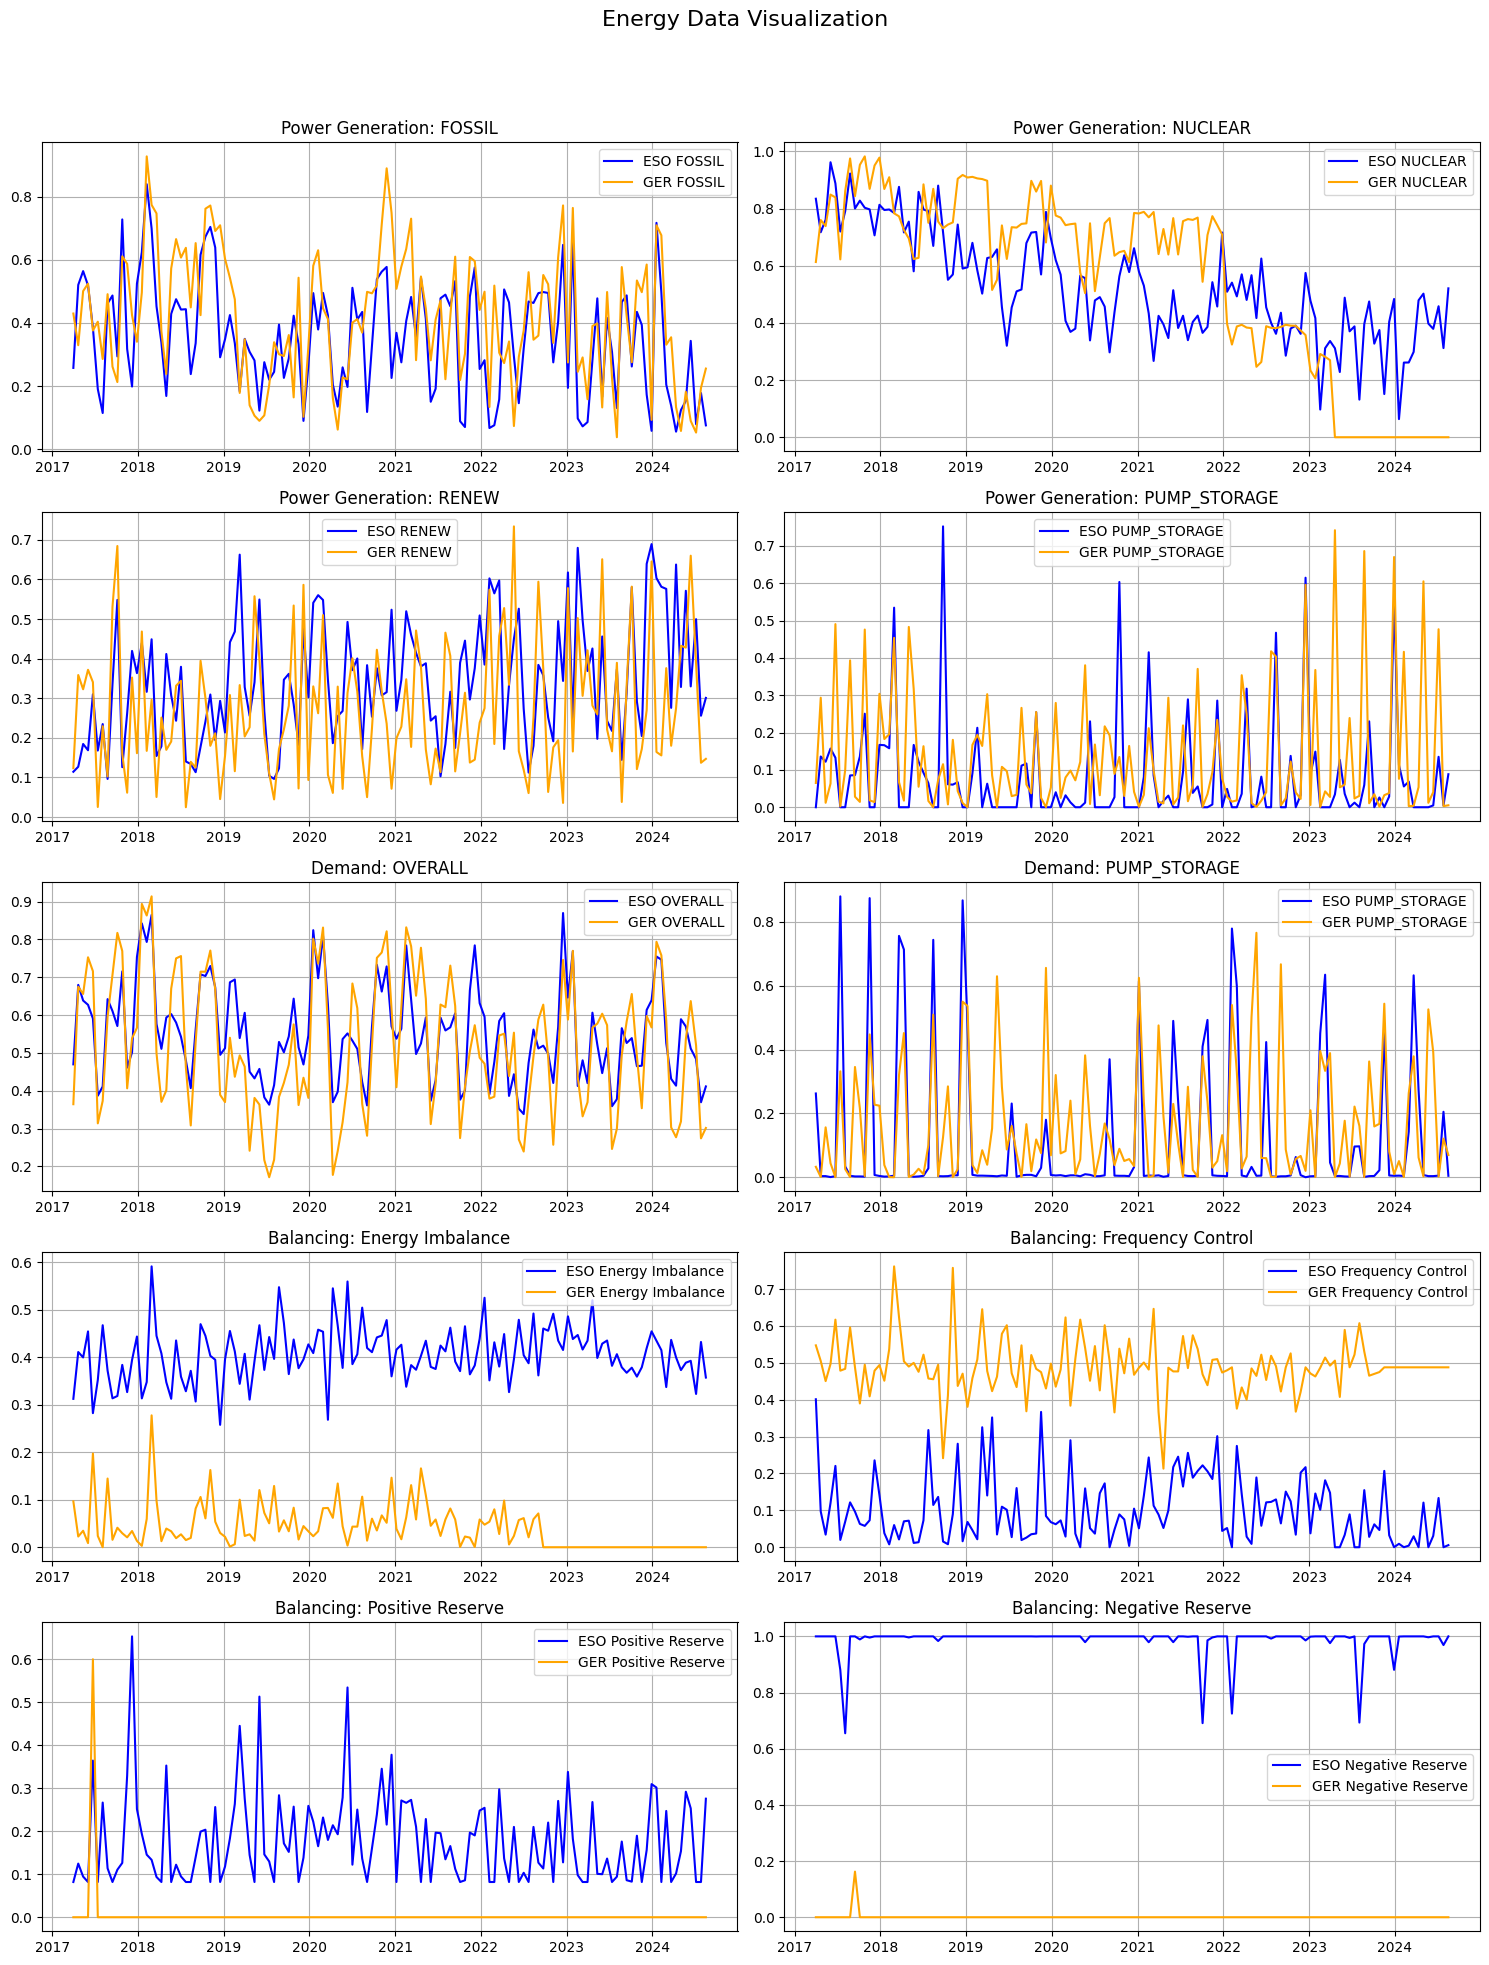

In [252]:
# VISUALIZE COMPARALE FEATURE OVER TIME
visualizer = Visualizer(df_eso, df_ger)
visualizer.plot_data(n=1000)

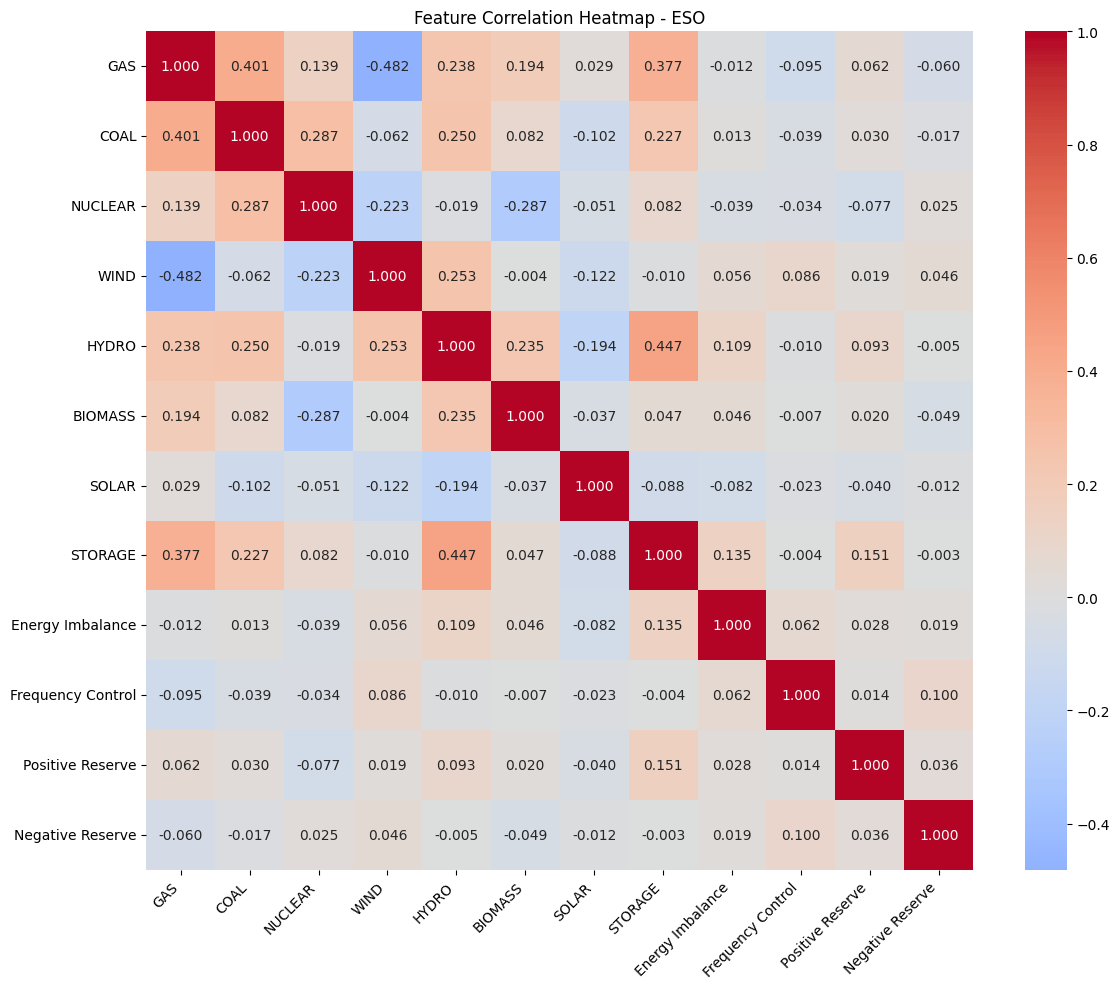

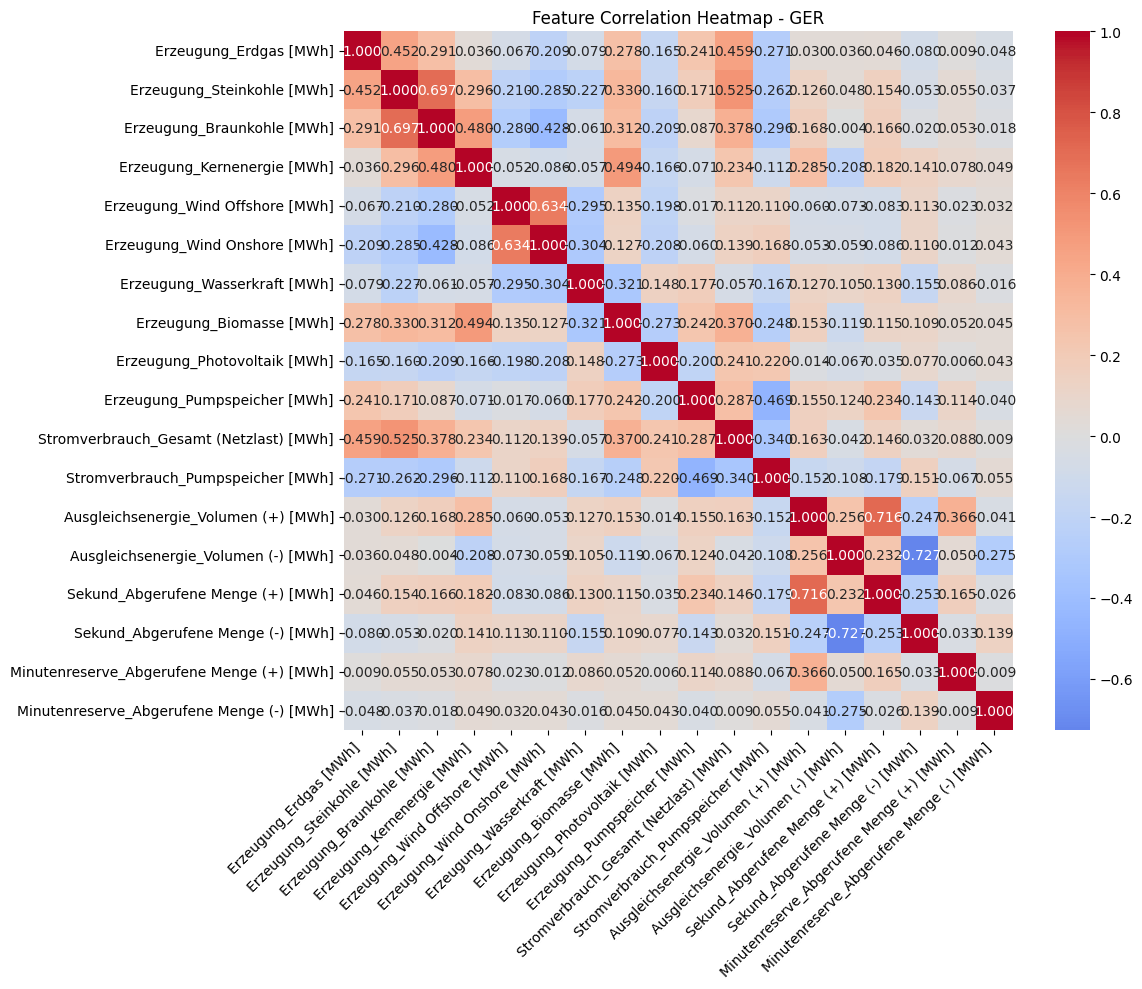

In [253]:
# VISUALIZE CORRELATION HEATMAP of COMPARABLE FEATURES
features_eso = ['GAS', 'COAL', 'NUCLEAR', 'WIND', 'HYDRO', 'BIOMASS', 'SOLAR', 'STORAGE',
               'Energy Imbalance', 'Frequency Control', 'Positive Reserve', 'Negative Reserve']

# Plot GER features
features_ger = ['Erzeugung_Erdgas [MWh]', 'Erzeugung_Steinkohle [MWh]', 'Erzeugung_Braunkohle [MWh]',
               'Erzeugung_Kernenergie [MWh]', 'Erzeugung_Wind Offshore [MWh]', 'Erzeugung_Wind Onshore [MWh]',
               'Erzeugung_Wasserkraft [MWh]', 'Erzeugung_Biomasse [MWh]', 'Erzeugung_Photovoltaik [MWh]',
               'Erzeugung_Pumpspeicher [MWh]',
               'Stromverbrauch_Gesamt (Netzlast) [MWh]', 'Stromverbrauch_Pumpspeicher [MWh]',
               'Ausgleichsenergie_Volumen (+) [MWh]', 'Ausgleichsenergie_Volumen (-) [MWh]',
               'Sekund_Abgerufene Menge (+) [MWh]', 'Sekund_Abgerufene Menge (-) [MWh]', 'Minutenreserve_Abgerufene Menge (+) [MWh]', 'Minutenreserve_Abgerufene Menge (-) [MWh]']

visualizer = Visualizer(df_eso, df_ger)
visualizer.plot_correlation_heatmap(features_eso, features_ger)


# SPLIT THE DATA

![Train Test Split for modeling process](../../data/figures/modeling_process.png)

In [254]:
## SPLITTING DATA
# ESO

target_name = 'FOSSIL'

eso_combine_cols = df_eso['GAS'] + df_eso['COAL']
df_eso[target_name] = eso_combine_cols 

eso_target = df_eso[target_name]

X_eso_dd = df_eso.loc[:, ~df_eso.columns.isin(eso_target + eso_combine_cols)]
y_eso_dd = eso_target

# Drop the target column explicitly
X_eso_dd = df_eso.drop(columns=[target_name])

X_train_eso, X_test_eso, y_train_eso, y_test_eso = train_test_split(X_eso_dd, y_eso_dd, test_size=0.25, random_state=42)

y_train_eso = pd.DataFrame({
    'ID': X_train_eso['ID'],
    target_name: y_train_eso.values
}).set_index(X_train_eso.index)

y_test_eso = pd.DataFrame({
    'ID': X_test_eso['ID'],
    target_name: y_test_eso.values
}).set_index(X_test_eso.index)

# GER
ger_combine_cols = df_ger['Erzeugung_Erdgas [MWh]'] + df_ger['Erzeugung_Steinkohle [MWh]'] + df_ger['Erzeugung_Braunkohle [MWh]']
df_ger[target_name] = ger_combine_cols

ger_target = df_ger[target_name]

X_ger_dd = df_ger.loc[:, ~df_ger.columns.isin(ger_target + ger_combine_cols)]
y_ger_dd = ger_target

# Drop the target column explicitly
X_ger_dd = df_ger.drop(columns=[target_name])

X_train_ger, X_test_ger, y_train_ger, y_test_ger = train_test_split(X_ger_dd, y_ger_dd, test_size=0.25, random_state=42)


y_train_ger = pd.DataFrame({
    'ID': X_train_ger['ID'],
    target_name: y_train_ger.values
}).set_index(X_train_ger.index)

y_test_ger = pd.DataFrame({
    'ID': X_test_ger['ID'],
    target_name: y_test_ger.values
}).set_index(X_test_ger.index)

In [255]:
print(f'X_train_eso \n{X_train_eso.head()}')

X_train_eso 
                        ID  Energy Imbalance  Frequency Control  \
89175  2022-05-04 06:00:00        -16515.244         578.516000   
100064 2022-12-18 01:30:00             0.000        8920.840501   
40319  2019-07-20 19:00:00         -2011.985        2821.572000   
46410  2019-11-24 19:30:00          1392.689        7098.226000   
3761   2017-06-18 08:30:00         10146.855        1303.764000   

        Positive Reserve  Negative Reserve  Constraints        Other  \
89175       37552.501000             0.000        0.000  1117.232000   
100064     202422.190536        -23009.822        0.000     8.844963   
40319       10078.115000             0.000    27436.721   228.160000   
46410       18712.740740             0.000        0.000   267.663264   
3761         3449.435000             0.000    29120.414     2.749000   

        Energy Imbalance (MWh)  Frequency Control Offers (MWh)  \
89175                 -158.086                           0.000   
100064             

In [256]:
print(f'X_test_eso \n{X_test_eso.head()}')

X_test_eso 
                       ID  Energy Imbalance  Frequency Control  \
59462 2020-08-22 20:30:00         31966.337         256.218000   
96964 2022-10-13 12:30:00        -78243.891         388.265000   
53398 2020-04-18 12:00:00         34528.172        1043.045000   
61532 2020-10-04 23:30:00         22809.810         255.903403   
69743 2021-03-25 05:00:00         23816.665        7424.078571   

       Positive Reserve  Negative Reserve  Constraints        Other  \
59462       8248.861000             0.000  68772.61100   493.797000   
96964          0.000000             0.000  18952.54200  1197.026000   
53398       3643.922859             0.000  34794.66325  1147.142887   
61532       2968.637873             0.000  56028.43752    45.766206   
69743       2100.055161            20.913  40225.47779   418.222475   

       Energy Imbalance (MWh)  Frequency Control Offers (MWh)  \
59462                 679.412                           9.167   
96964                -647.018     

In [257]:
print(f'y_train_eso \n{y_train_eso.head()}')


y_train_eso 
                        ID   FOSSIL
89175  2022-05-04 06:00:00  19410.0
100064 2022-12-18 01:30:00   6847.0
40319  2019-07-20 19:00:00   8829.0
46410  2019-11-24 19:30:00  20053.0
3761   2017-06-18 08:30:00  10623.0


In [258]:
print(f'y_test_eso \n{y_test_eso.head()}')

y_test_eso 
                       ID   FOSSIL
59462 2020-08-22 20:30:00   8153.0
96964 2022-10-13 12:30:00  19183.0
53398 2020-04-18 12:00:00  10878.0
61532 2020-10-04 23:30:00   6074.0
69743 2021-03-25 05:00:00   6196.0


# Generate a dataset for qucik testing

In [259]:
### Generate a dataset for quick testing
np.random.seed(42)  # For reproducibility
y = np.random.uniform(1, 1000, 240)  # Random values between 1 and 100
id_timestamps = pd.date_range(start="2017-04-01 00:00:00", periods=240, freq="30min")
# Calculate X1, X2, X3 based on y

X1 = y**(1/2)  # Square root of y
X2 = y + 4     # y + 4
X3 = np.log(y) # Natural logarithm of y
X4 = y**2

# Create the DataFrame
df = pd.DataFrame({
    "ID": id_timestamps,
    'FOSSIL': y, 
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4
})
X = df[['ID', 'X1', 'X2', 'X3', 'X4']]
y = df['FOSSIL']

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
y_train = pd.DataFrame({
    'ID': X_train['ID'],
    'FOSSIL': y_train.values
}).set_index(X_train.index)
y_test = pd.DataFrame({
    'ID': X_test['ID'],
    'FOSSIL': y_test.values
}).set_index(X_test.index)

# NORMALIZE THE TRAIN DATA

In [260]:
## NORMALIZE
def normalize(X_train, X_test, y_train, y_test):

    # Sort both datasets by ID
    X_train = X_train.sort_values('ID')
    X_test = X_test.sort_values('ID')

     # Initialize scaler
    X_scaler = MinMaxScaler(clip=True)
    y_scaler = MinMaxScaler(clip=True)
    
    # Create copies
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    y_train_scaled = y_train.copy()
    y_test_scaled = y_test.copy()
    
    # Scale X
    for column in X_train.columns:
        if column != 'ID':
            X_train_scaled[column] = X_scaler.fit_transform(X_train[[column]])
            X_test_scaled[column] = X_scaler.transform(X_test[[column]])
    
    # Scale y
    for column in y_train.columns:
        if column != 'ID':
            y_train_scaled[column] = y_scaler.fit_transform(y_train[[column]])
            y_test_scaled[column] = y_scaler.transform(y_test[[column]])
    
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled

In [261]:

# Use data normlaization function
X_train, X_test, y_train, y_test = normalize(X_train, X_test, y_train, y_test)

X_train_eso, X_test_eso, y_train_eso, y_test_eso = normalize(X_train_eso, X_test_eso, y_train_eso, y_test_eso)
X_train_ger, X_test_ger, y_train_ger, y_test_ger = normalize(X_train_ger, X_test_ger, y_train_ger, y_test_ger)

# Save for modeling
processed_dir = Path('..') / '..' / 'data' / 'processed' / 'Visualizer'
processed_dir.mkdir(parents=True, exist_ok=True)

# Test
X_train.to_csv(processed_dir / 'test' / 'X_train.csv', index=False)
y_train.to_csv(processed_dir / 'test' / 'y_train.csv', index=False)

X_test.to_csv(processed_dir / 'test' / 'X_eval.csv', index=False)
y_test.to_csv(processed_dir / 'test' / 'y_eval.csv', index=False)

# ESO
X_train_eso.to_csv(processed_dir / 'eso' / 'X_train_eso.csv', index=False)
y_train_eso.to_csv(processed_dir / 'eso' / 'y_train_eso.csv', index=False)

X_test_eso.to_csv(processed_dir / 'eso' / 'X_eval_eso.csv', index=False)
y_test_eso.to_csv(processed_dir / 'eso' / 'y_eval_eso.csv', index=False)

# GER
X_train_ger.to_csv(processed_dir / 'ger' / 'X_train_ger.csv', index=False)
y_train_ger.to_csv(processed_dir / 'ger' / 'y_train_ger.csv', index=False)

X_test_ger.to_csv(processed_dir / 'ger' / 'X_eval_ger.csv', index=False)
y_test_ger.to_csv(processed_dir / 'ger' / 'y_eval_ger.csv', index=False)



# Print correlation of normalized dataset 

In [262]:
thres = 0.7
def find_high_correlations(df, threshold=thres, output_path=None):
    """Finds and saves highly correlated feature pairs"""
    # Get correlation matrix without ID column
    corr_matrix = df.drop('ID', axis=1, errors='ignore').corr()
    
    # Store high correlations
    high_corr = {}
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr = corr_matrix.iloc[i, j]
            if threshold <= abs(corr) < 1.0:
                feat1, feat2 = corr_matrix.columns[i], corr_matrix.columns[j]
                if feat1.split('.')[0] != feat2.split('.')[0]:
                    high_corr[(feat1, feat2)] = round(corr, 3)
    
    # Sort and save results
    sorted_corr = dict(sorted(high_corr.items(), key=lambda x: abs(x[1]), reverse=True))
    if output_path:
        with open(output_path, 'w') as f:
            f.write(f"High Correlations (threshold >= {threshold}):\n")
            for (f1, f2), corr in sorted_corr.items():
                f.write(f"{f1} - {f2}: {corr}\n")
                
    return sorted_corr

eso_corr = 'eso_corr'; ger_corr = 'ger_corr'
_ = find_high_correlations(X_train_eso, output_path=Path(f'{data_path}/../Visualizer/eso/{eso_corr}_tresh{thres}.txt'))
_ = find_high_correlations(X_train_ger, output_path=Path(f'{data_path}/../Visualizer/ger/{ger_corr}_tresh{thres}.txt'))